In [1]:
import pandas as pd
import numpy as np

In [2]:
raw = pd.read_csv("../data/TBI PUD 10-08-2013.csv")

In [3]:
doc = pd.read_excel("../data/TBI PUD Documentation 10-08-2013.xlsx")

In [4]:
raw.shape

(43399, 125)

In [5]:
raw.head()

,PatNum,EmplType,Certification,InjuryMech,High_impact_InjSev,Amnesia_verb,LOCSeparate,LocLen,Seiz,SeizOccur,...,Finding20,Finding21,Finding22,Finding23,DeathTBI,HospHead,HospHeadPosCT,Intub24Head,Neurosurgery,PosIntFinal
0,1,3.0,3,11.0,2.0,0.0,0.0,92.0,0.0,92.0,...,92,92,92,92,0.0,0.0,0,0.0,0.0,0.0
1,2,5.0,3,8.0,2.0,0.0,0.0,92.0,0.0,92.0,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0
2,3,5.0,3,5.0,2.0,NaN,NaN,92.0,NaN,92.0,...,0,0,0,0,0.0,1.0,0,0.0,0.0,0.0
3,4,5.0,3,6.0,1.0,91.0,0.0,92.0,0.0,92.0,...,92,92,92,92,0.0,0.0,0,0.0,0.0,0.0
4,5,3.0,3,12.0,2.0,91.0,0.0,92.0,0.0,92.0,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0


In [6]:
raw.dtypes

PatNum                  int64
EmplType              float64
Certification           int64
InjuryMech            float64
High_impact_InjSev    float64
                       ...   
HospHead              float64
HospHeadPosCT           int64
Intub24Head           float64
Neurosurgery          float64
PosIntFinal           float64
Length: 125, dtype: object

In [7]:
raw.columns.tolist()

['PatNum',
 'EmplType',
 'Certification',
 'InjuryMech',
 'High_impact_InjSev',
 'Amnesia_verb',
 'LOCSeparate',
 'LocLen',
 'Seiz',
 'SeizOccur',
 'SeizLen',
 'ActNorm',
 'HA_verb',
 'HASeverity',
 'HAStart',
 'Vomit',
 'VomitNbr',
 'VomitStart',
 'VomitLast',
 'Dizzy',
 'Intubated',
 'Paralyzed',
 'Sedated',
 'GCSEye',
 'GCSVerbal',
 'GCSMotor',
 'GCSTotal',
 'GCSGroup',
 'AMS',
 'AMSAgitated',
 'AMSSleep',
 'AMSSlow',
 'AMSRepeat',
 'AMSOth',
 'SFxPalp',
 'SFxPalpDepress',
 'FontBulg',
 'SFxBas',
 'SFxBasHem',
 'SFxBasOto',
 'SFxBasPer',
 'SFxBasRet',
 'SFxBasRhi',
 'Hema',
 'HemaLoc',
 'HemaSize',
 'Clav',
 'ClavFace',
 'ClavNeck',
 'ClavFro',
 'ClavOcc',
 'ClavPar',
 'ClavTem',
 'NeuroD',
 'NeuroDMotor',
 'NeuroDSensory',
 'NeuroDCranial',
 'NeuroDReflex',
 'NeuroDOth',
 'OSI',
 'OSIExtremity',
 'OSICut',
 'OSICspine',
 'OSIFlank',
 'OSIAbdomen',
 'OSIPelvis',
 'OSIOth',
 'Drugs',
 'CTForm1',
 'IndAge',
 'IndAmnesia',
 'IndAMS',
 'IndClinSFx',
 'IndHA',
 'IndHema',
 'IndLOC',
 'In

In [8]:
doc.shape

(135, 6)

In [9]:
doc.head(20)

,Dataset Programs,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Introduction:,This prospective observational cohort study en...,NaN,NaN,NaN,NaN
1,Inclusion/Exclusion for Public Use Dataset:,Children presenting within 24 hours of head tr...,NaN,NaN,NaN,NaN
2,Data Collection:,Trained site investigators and other emergency...,NaN,NaN,NaN,NaN
3,Outcomes:,We defined clinically-important TBI (ciTBI) a ...,NaN,NaN,NaN,NaN
4,Follow-up Procedures:,Patients were admitted to the hospital at emer...,NaN,NaN,NaN,NaN
5,TBI Prediction Rule:,A prediction rule for identifying children at ...,NaN,NaN,NaN,NaN
6,TBI Prediction Rule Article Reference:,"Kuppermann N, Holmes JF, Dayan PS, Hoyle JD, A...",NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN
9,Variable Name,Label/Description,Format Name and Values,Notes,NaN,NaN


In [10]:
doc.columns.tolist()

['Dataset Programs',
 'Unnamed: 1',
 'Unnamed: 2',
 'Unnamed: 3',
 'Unnamed: 4',
 'Unnamed: 5']

In [11]:
codebook = doc.iloc[10:, :4].copy()

codebook.columns = [
    "Variable",
    "Description",
    "Values",
    "Notes"
]

codebook.head(10)

,Variable,Description,Values,Notes
10,PatNum,Patient Number,Numeric,A randomly generated number that uniquely iden...
11,EmplType,Position of physician completing data sheet,EmplType\n1 Nurse Practitioner\n2 Physic...,An attending or fellow physician reviewed all ...
12,Certification,Certification of physician completing the form,CertType\n1 Emergency Medicine\n2 Pediatri...,NaN
13,InjuryMech,Injury mechanism,InjMech\n1 Occupant in motor vehicle \n ...,NaN
14,High_impact_InjSev,Severity of injury mechanism,InjSev\n1 Low\n2 Moderate\n3 High,Injury Severity based on the injury mechanism ...
15,Amnesia_verb,Does the patient have amnesia for the event?,YesNoPV\n0 No\n1 Yes\n91 Pre-verbal/Non-ve...,Pre-verbal is marked if the patient is too you...
16,LOCSeparate,History of loss of consciousness?,YesNoLOC\n0 No\n1 Yes\n2 Suspected,NaN
17,LocLen,Duration of loss of consciousness,LocLen\n1 < 5 sec\n2 5 sec - < 1 min\n3 ...,Not applicable is marked if history of loss of...
18,Seiz,Post-traumatic seizure?,YesNo\n0 No\n1 Yes,NaN
19,SeizOccur,When did the post-traumatic seizure occur?,SeizOcc\n1 Immediately on contact\n2 Withi...,Not applicable is marked if post-traumatic sei...


In [12]:
raw_vars = set(raw.columns)
doc_vars = set(codebook["Variable"].dropna())
raw_vars - doc_vars

set()

In [13]:
doc_vars - raw_vars

set()

In [14]:
raw.duplicated().sum()

np.int64(0)

In [15]:
raw["PatNum"].duplicated().sum()

np.int64(0)

In [16]:
missing = raw.isna().mean().sort_values(ascending=False)

missing.head(20)

Dizzy           0.368027
Ethnicity       0.367889
ActNorm         0.076845
Race            0.073919
LocLen          0.058895
Observed        0.054748
Amnesia_verb    0.052904
LOCSeparate     0.043595
Drugs           0.041890
HAStart         0.030692
GCSMotor        0.030185
GCSVerbal       0.029909
GCSEye          0.029678
HASeverity      0.024056
VomitLast       0.022858
CTSed           0.021060
Seiz            0.021014
HemaSize        0.017097
NeuroD          0.015208
HA_verb         0.015023
dtype: float64

### Initial data quality checks

The raw dataset contains 43,399 observations and 125 variables. All variables in the raw data are documented in the codebook, and there are no duplicate rows or duplicate patient IDs. Initial missingness checks show substantial variation across variables, but these rates only reflect values represented as `NaN`; special numeric codes must also be interpreted using the documentation.

In [17]:
raw["Amnesia_verb"].value_counts(dropna=False)

Amnesia_verb
0.0     21751
91.0    14805
1.0      4547
NaN      2296
Name: count, dtype: int64

In [18]:
raw["LOCSeparate"].value_counts(dropna=False)

LOCSeparate
0.0    34665
1.0     4830
2.0     2012
NaN     1892
Name: count, dtype: int64

In [19]:
raw["LocLen"].value_counts(dropna=False)

LocLen
92.0    36557
NaN      2556
2.0      1867
3.0      1133
1.0       922
4.0       364
Name: count, dtype: int64

In [20]:
raw["Seiz"].value_counts(dropna=False)

Seiz
0.0    41884
NaN      912
1.0      603
Name: count, dtype: int64

In [21]:
pd.crosstab(
    raw["LOCSeparate"],
    raw["LocLen"],
    dropna=False
)

LocLen,1.0,2.0,3.0,4.0,92.0,NaN
LOCSeparate,,,,,,
0.0,0,0,0,0,34665,0
1.0,540,1410,1018,326,0,1536
2.0,382,457,115,38,0,1020
NaN,0,0,0,0,1892,0


In [22]:
pd.crosstab(
    raw["Seiz"],
    raw["SeizOccur"],
    dropna=False
)

SeizOccur,1.0,2.0,3.0,92.0,NaN
Seiz,,,,,
0.0,0,0,0,41884,0
1.0,253,210,69,0,71
NaN,0,0,0,912,0


LOCSeparate/LocLen and Seiz/SeizOccur were internally consistent: observations without the condition used the not-applicable code for the follow-up variable. However, the follow-up variable was sometimes missing even when the condition was present.

In [23]:
for col in [
    "AgeinYears",
    "Gender",
    "Race",
    "Ethnicity",
    "GCSTotal",
    "CTDone",
    "PosCT",
    "Finding1"
]:
    print("\n", col)
    print(raw[col].value_counts(dropna=False).sort_index())


 AgeinYears
AgeinYears
0     5441
1     5463
2     3910
3     2956
4     2472
5     2186
6     2003
7     1795
8     1573
9     1498
10    1552
11    1602
12    1716
13    1775
14    1939
15    1905
16    1942
17    1671
Name: count, dtype: int64

 Gender
Gender
1.0    27055
2.0    16341
NaN        3
Name: count, dtype: int64

 Race
Race
1.0     21857
2.0     15992
3.0       861
4.0        64
5.0        78
90.0     1339
NaN      3208
Name: count, dtype: int64

 Ethnicity
Ethnicity
1.0     5275
2.0    22158
NaN    15966
Name: count, dtype: int64

 GCSTotal
GCSTotal
3       177
4        22
5        18
6        49
7        42
8        46
9        61
10       54
11       93
12      102
13      305
14     1344
15    41086
Name: count, dtype: int64

 CTDone
CTDone
0    27500
1    15899
Name: count, dtype: int64

 PosCT
PosCT
0     14743
1      1156
92    27500
Name: count, dtype: int64

 Finding1
Finding1
0     15876
1        23
92    27500
Name: count, dtype: int64


In [24]:
raw["AgeinYears"].describe()

count    43399.000000
mean         6.581419
std          5.533878
min          0.000000
25%          1.000000
50%          5.000000
75%         12.000000
max         17.000000
Name: AgeinYears, dtype: float64

In [25]:
codebook[
    codebook["Variable"].isin(
        ["Race", "Ethnicity", "CTDone", "PosCT", "Finding1"]
    )
]

,Variable,Description,Values,Notes
104,Ethnicity,Ethnicity,Ethn\n1 Hispanic\n2 Non-Hispanic,As reported by the physician not by the patien...
105,Race,Race,Race\n1 White\n2 Black\n3 Asian\n4 America...,As reported by the physician not by the patien...
108,CTDone,Any head CT performed?,YesNo\n0 No\n1 Yes,This indicates if any head CT was performed re...
110,PosCT,TBI on CT (determined by PI),YesNoNA\n0 No\n1 Yes\n92 Not applicable,The first traumatic head CT of any patient was...
111,Finding1,Traumatic finding: cerebellar hemorrhage,YesNoNA\n0 No\n1 Yes\n92 Not applicable,Not applicable is marked if no head CT was per...


In [26]:
pd.crosstab(
    raw["CTDone"],
    raw["PosCT"],
    dropna=False
)

PosCT,0,1,92
CTDone,,,
0,0,0,27500
1,14743,1156,0


In [27]:
pd.crosstab(
    raw["CTDone"],
    raw["Finding1"],
    dropna=False
)

Finding1,0,1,92
CTDone,,,
0,0,0,27500
1,15876,23,0


logical consistency check: no issues so far

In [28]:
special_codes = codebook[
    codebook["Values"].astype(str).str.contains(r"\b90\b|\b91\b|\b92\b", regex=True)
]

special_codes[["Variable", "Description", "Values", "Notes"]]

,Variable,Description,Values,Notes
12,Certification,Certification of physician completing the form,CertType\n1 Emergency Medicine\n2 Pediatri...,NaN
13,InjuryMech,Injury mechanism,InjMech\n1 Occupant in motor vehicle \n ...,NaN
15,Amnesia_verb,Does the patient have amnesia for the event?,YesNoPV\n0 No\n1 Yes\n91 Pre-verbal/Non-ve...,Pre-verbal is marked if the patient is too you...
17,LocLen,Duration of loss of consciousness,LocLen\n1 < 5 sec\n2 5 sec - < 1 min\n3 ...,Not applicable is marked if history of loss of...
19,SeizOccur,When did the post-traumatic seizure occur?,SeizOcc\n1 Immediately on contact\n2 Withi...,Not applicable is marked if post-traumatic sei...
...,...,...,...,...
124,Finding14,Traumatic finding: traumatic infarction,YesNoNA\n0 No\n1 Yes\n92 Not applicable,Not applicable is marked if no head CT was per...
125,Finding20,Traumatic finding (extra finding by PI): diffu...,YesNoNA\n0 No\n1 Yes\n92 Not applicable,Not applicable is marked if no head CT was per...
126,Finding21,Traumatic finding (extra finding by PI): herni...,YesNoNA\n0 No\n1 Yes\n92 Not applicable,Not applicable is marked if no head CT was per...
127,Finding22,Traumatic finding (extra finding by PI):shear ...,YesNoNA\n0 No\n1 Yes\n92 Not applicable,Not applicable is marked if no head CT was per...


In [29]:
special_in_data = []

for col in raw.columns:
    if pd.api.types.is_numeric_dtype(raw[col]):
        vals = set(raw[col].dropna().unique())
        if any(v in vals for v in [90, 91, 92]):
            special_in_data.append(col)

special_in_data

['PatNum',
 'Certification',
 'InjuryMech',
 'Amnesia_verb',
 'LocLen',
 'SeizOccur',
 'SeizLen',
 'HA_verb',
 'HASeverity',
 'HAStart',
 'VomitNbr',
 'VomitStart',
 'VomitLast',
 'AMSAgitated',
 'AMSSleep',
 'AMSSlow',
 'AMSRepeat',
 'AMSOth',
 'SFxPalpDepress',
 'SFxBasHem',
 'SFxBasOto',
 'SFxBasPer',
 'SFxBasRet',
 'SFxBasRhi',
 'HemaLoc',
 'HemaSize',
 'ClavFace',
 'ClavNeck',
 'ClavFro',
 'ClavOcc',
 'ClavPar',
 'ClavTem',
 'NeuroDMotor',
 'NeuroDSensory',
 'NeuroDCranial',
 'NeuroDReflex',
 'NeuroDOth',
 'OSIExtremity',
 'OSICut',
 'OSICspine',
 'OSIFlank',
 'OSIAbdomen',
 'OSIPelvis',
 'OSIOth',
 'IndAge',
 'IndAmnesia',
 'IndAMS',
 'IndClinSFx',
 'IndHA',
 'IndHema',
 'IndLOC',
 'IndMech',
 'IndNeuroD',
 'IndRqstMD',
 'IndRqstParent',
 'IndRqstTrauma',
 'IndSeiz',
 'IndVomit',
 'IndXraySFx',
 'IndOth',
 'CTSed',
 'CTSedAgitate',
 'CTSedAge',
 'CTSedRqst',
 'CTSedOth',
 'AgeInMonth',
 'Race',
 'EDDisposition',
 'EDCT',
 'PosCT',
 'Finding1',
 'Finding2',
 'Finding3',
 'Finding4

In [30]:
special_doc = codebook[
    codebook["Values"].astype(str).str.contains(
        "Not applicable|Unknown|Pre-verbal|Other",
        case=False,
        regex=True
    )
]

special_doc[["Variable", "Description", "Values", "Notes"]]

,Variable,Description,Values,Notes
12,Certification,Certification of physician completing the form,CertType\n1 Emergency Medicine\n2 Pediatri...,NaN
13,InjuryMech,Injury mechanism,InjMech\n1 Occupant in motor vehicle \n ...,NaN
15,Amnesia_verb,Does the patient have amnesia for the event?,YesNoPV\n0 No\n1 Yes\n91 Pre-verbal/Non-ve...,Pre-verbal is marked if the patient is too you...
17,LocLen,Duration of loss of consciousness,LocLen\n1 < 5 sec\n2 5 sec - < 1 min\n3 ...,Not applicable is marked if history of loss of...
19,SeizOccur,When did the post-traumatic seizure occur?,SeizOcc\n1 Immediately on contact\n2 Withi...,Not applicable is marked if post-traumatic sei...
...,...,...,...,...
124,Finding14,Traumatic finding: traumatic infarction,YesNoNA\n0 No\n1 Yes\n92 Not applicable,Not applicable is marked if no head CT was per...
125,Finding20,Traumatic finding (extra finding by PI): diffu...,YesNoNA\n0 No\n1 Yes\n92 Not applicable,Not applicable is marked if no head CT was per...
126,Finding21,Traumatic finding (extra finding by PI): herni...,YesNoNA\n0 No\n1 Yes\n92 Not applicable,Not applicable is marked if no head CT was per...
127,Finding22,Traumatic finding (extra finding by PI):shear ...,YesNoNA\n0 No\n1 Yes\n92 Not applicable,Not applicable is marked if no head CT was per...


In [31]:
not_applicable = codebook[
    codebook["Values"].astype(str).str.contains(
        "Not applicable", case=False, na=False
    )
]

not_applicable[["Variable", "Values"]]

,Variable,Values
17,LocLen,LocLen\n1 < 5 sec\n2 5 sec - < 1 min\n3 ...
19,SeizOccur,SeizOcc\n1 Immediately on contact\n2 Withi...
20,SeizLen,SeizLen\n1 < 1 min\n2 1 - < 5 min\n3 5 - ...
23,HASeverity,HASev\n1 Mild (barely noticeable)\n2 Moder...
24,HAStart,Start\n1 Before head injury\n2 Within 1 hr o...
...,...,...
124,Finding14,YesNoNA\n0 No\n1 Yes\n92 Not applicable
125,Finding20,YesNoNA\n0 No\n1 Yes\n92 Not applicable
126,Finding21,YesNoNA\n0 No\n1 Yes\n92 Not applicable
127,Finding22,YesNoNA\n0 No\n1 Yes\n92 Not applicable


In [32]:
unknown_codes = codebook[
    codebook["Values"].astype(str).str.contains(
        "Unknown", case=False, na=False
    )
]

unknown_codes[["Variable", "Values"]]

,Variable,Values


In [33]:
clean = raw.copy()

In [34]:
na92_vars = codebook[
    codebook["Values"].astype(str).str.contains(
        r"92\s+Not applicable",
        case=False,
        na=False,
        regex=True
    )
]["Variable"].tolist()

na92_vars[:20], len(na92_vars)

(['LocLen',
  'SeizOccur',
  'SeizLen',
  'HASeverity',
  'HAStart',
  'VomitNbr',
  'VomitStart',
  'VomitLast',
  'AMSAgitated',
  'AMSSleep',
  'AMSSlow',
  'AMSRepeat',
  'AMSOth',
  'SFxPalpDepress',
  'SFxBasHem',
  'SFxBasOto',
  'SFxBasPer',
  'SFxBasRet',
  'SFxBasRhi',
  'HemaLoc'],
 80)

In [35]:
for col in na92_vars:
    if col in clean.columns:
        clean[col] = clean[col].replace(92, np.nan)

In [36]:
clean["PosCT"].value_counts(dropna=False)

PosCT
NaN    27500
0.0    14743
1.0     1156
Name: count, dtype: int64

In [37]:
clean_missing = clean.isna().mean().sort_values(ascending=False)
clean_missing.head(20)

SFxPalpDepress    0.996106
SFxBasHem         0.990875
SFxBasOto         0.990875
SFxBasPer         0.990875
SFxBasRet         0.990875
SFxBasRhi         0.990875
SeizLen           0.988802
SeizOccur         0.987742
CTSedOth          0.984931
CTSedRqst         0.984931
CTSedAge          0.984931
CTSedAgitate      0.984931
NeuroDReflex      0.984147
NeuroDSensory     0.984147
NeuroDCranial     0.984147
NeuroDMotor       0.984147
NeuroDOth         0.984147
LocLen            0.901242
OSIExtremity      0.894767
OSICut            0.894767
dtype: float64

In [38]:
comparison = pd.DataFrame({
    "raw_missing": raw.isna().mean(),
    "clean_missing": clean.isna().mean()
})

comparison["increase"] = (
    comparison["clean_missing"] - comparison["raw_missing"]
)

comparison.sort_values("increase", ascending=False).head(20)

,raw_missing,clean_missing,increase
SFxPalpDepress,0.001267,0.996106,0.994839
SFxBasOto,0.000000,0.990875,0.990875
SFxBasPer,0.000000,0.990875,0.990875
SFxBasRhi,0.000000,0.990875,0.990875
SFxBasHem,0.000000,0.990875,0.990875
SFxBasRet,0.000000,0.990875,0.990875
SeizLen,0.002696,0.988802,0.986106
SeizOccur,0.001636,0.987742,0.986106
CTSedAgitate,0.000000,0.984931,0.984931
CTSedAge,0.000000,0.984931,0.984931


In [39]:
raw_missing = raw.isna().mean().sort_values(ascending=False)
raw_missing.head(15)

Dizzy           0.368027
Ethnicity       0.367889
ActNorm         0.076845
Race            0.073919
LocLen          0.058895
Observed        0.054748
Amnesia_verb    0.052904
LOCSeparate     0.043595
Drugs           0.041890
HAStart         0.030692
GCSMotor        0.030185
GCSVerbal       0.029909
GCSEye          0.029678
HASeverity      0.024056
VomitLast       0.022858
dtype: float64

In [40]:
clean.shape

(43399, 125)

In [41]:
clean[["AgeinYears", "GCSTotal", "Gender", "Race", "Ethnicity"]].describe(include="all")

,AgeinYears,GCSTotal,Gender,Race,Ethnicity
count,43399.000000,43399.000000,43396.000000,40191.000000,27433.000000
mean,6.581419,14.840711,1.376555,4.418402,1.807713
std,5.533878,1.032624,0.484527,15.897961,0.394104
min,0.000000,3.000000,1.000000,1.000000,1.000000
25%,1.000000,15.000000,1.000000,1.000000,2.000000
50%,5.000000,15.000000,1.000000,1.000000,2.000000
75%,12.000000,15.000000,2.000000,2.000000,2.000000
max,17.000000,15.000000,2.000000,90.000000,2.000000


In [42]:
raw["Ethnicity"].value_counts(dropna=False)
raw["Race"].value_counts(dropna=False)
raw["Dizzy"].value_counts(dropna=False)

Dizzy
0.0    24821
NaN    15972
1.0     2606
Name: count, dtype: int64

In [43]:
codebook[
    codebook["Variable"].isin(["Ethnicity", "Race", "Dizzy"])
]

,Variable,Description,Values,Notes
29,Dizzy,Dizziness (at ED evaluation)?,YesNo\n0 No\n1 Yes,NaN
104,Ethnicity,Ethnicity,Ethn\n1 Hispanic\n2 Non-Hispanic,As reported by the physician not by the patien...
105,Race,Race,Race\n1 White\n2 Black\n3 Asian\n4 America...,As reported by the physician not by the patien...


In [44]:
clean = raw.copy()

In [45]:
na92_vars = codebook[
    codebook["Values"].astype(str).str.contains(
        r"92\s+Not applicable",
        case=False,
        na=False,
        regex=True
    )
]["Variable"].tolist()

for col in na92_vars:
    if col in clean.columns:
        clean[col] = clean[col].replace(92, np.nan)


 AgeinYears
AgeinYears
0     5441
1     5463
2     3910
3     2956
4     2472
5     2186
6     2003
7     1795
8     1573
9     1498
10    1552
11    1602
12    1716
13    1775
14    1939
15    1905
16    1942
17    1671
Name: count, dtype: int64

 Gender
Gender
1.0    27055
2.0    16341
NaN        3
Name: count, dtype: int64

 Race
Race
1.0     21857
2.0     15992
3.0       861
4.0        64
5.0        78
90.0     1339
NaN      3208
Name: count, dtype: int64

 Ethnicity
Ethnicity
1.0     5275
2.0    22158
NaN    15966
Name: count, dtype: int64

 GCSTotal
GCSTotal
3       177
4        22
5        18
6        49
7        42
8        46
9        61
10       54
11       93
12      102
13      305
14     1344
15    41086
Name: count, dtype: int64

 CTDone
CTDone
0    27500
1    15899
Name: count, dtype: int64

 PosCT
PosCT
0     14743
1      1156
92    27500
Name: count, dtype: int64

 Finding1
Finding1
0     15876
1        23
92    27500
Name: count, dtype: int64

 LOCSeparate
          

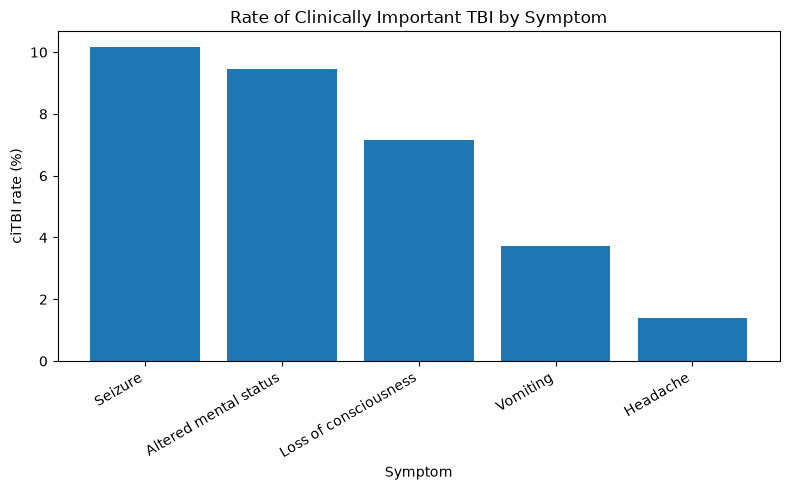

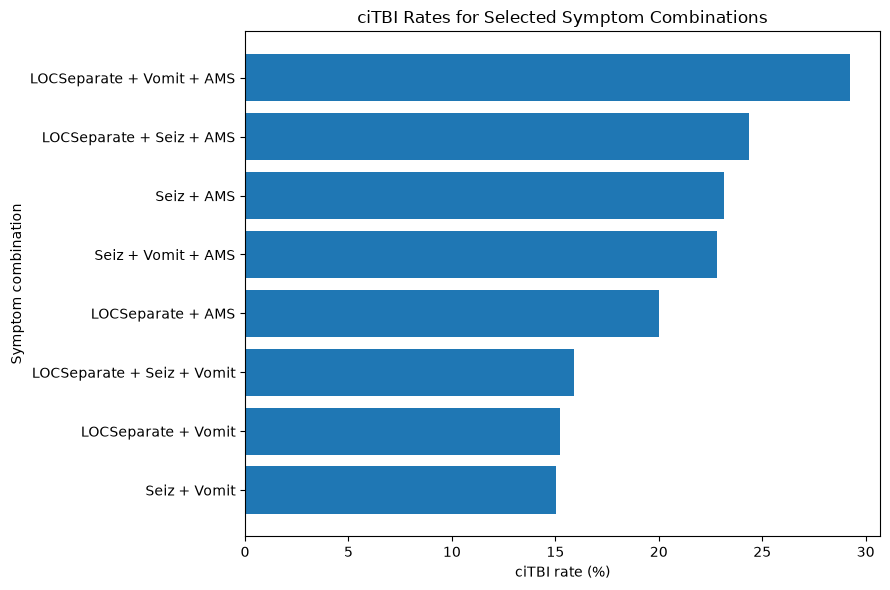

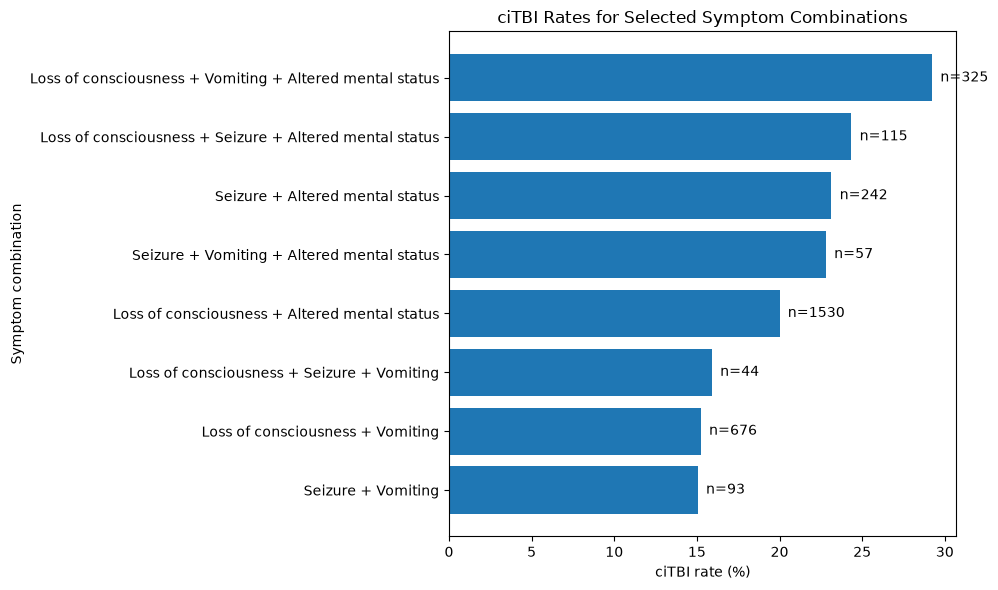

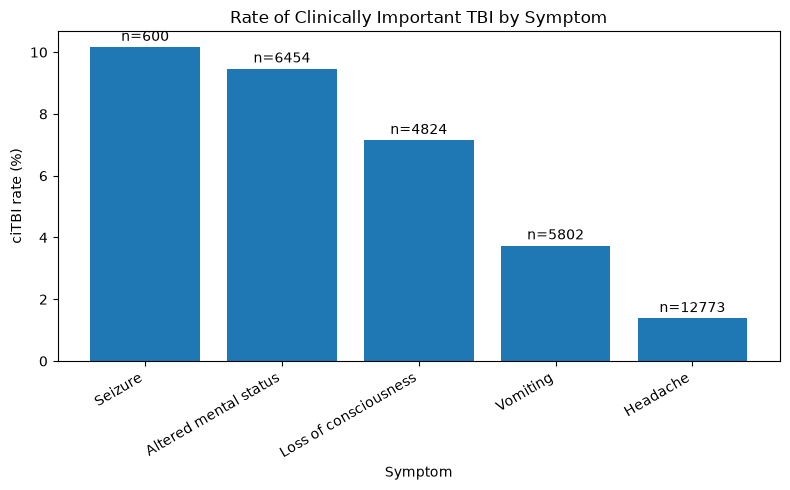

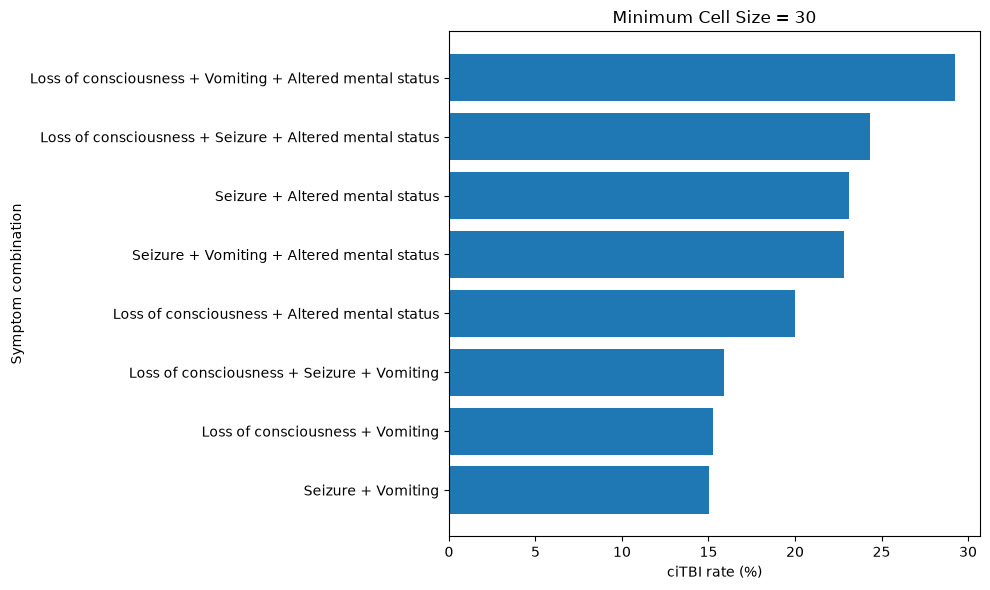

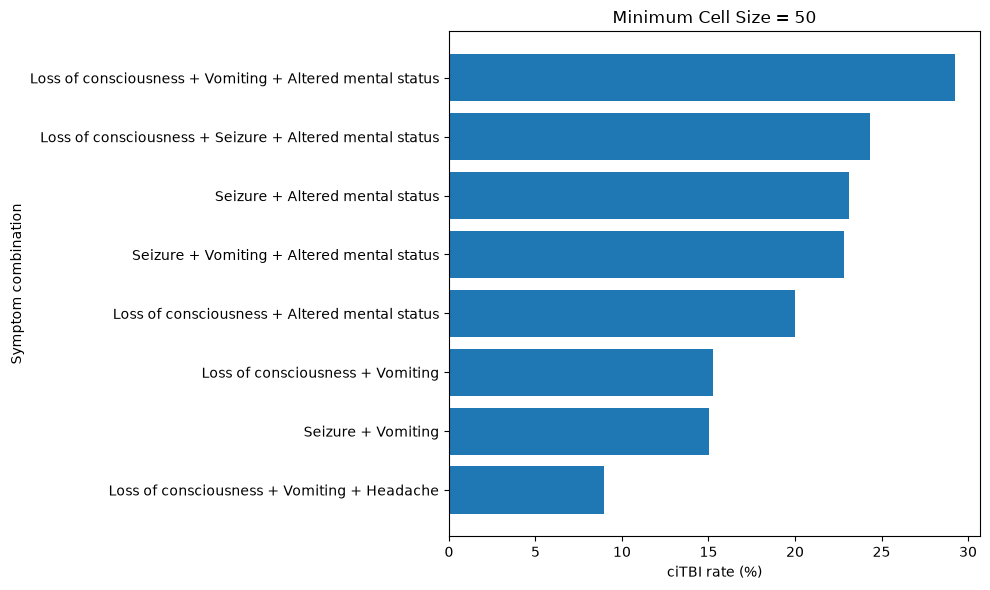

Logistic Regression
[[7291 1232]
 [  33  120]]
              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92      8523
         1.0       0.09      0.78      0.16       153

    accuracy                           0.85      8676
   macro avg       0.54      0.82      0.54      8676
weighted avg       0.98      0.85      0.91      8676

Sensitivity: 0.7843137254901961
Decision Tree
[[7494 1029]
 [  44  109]]
              precision    recall  f1-score   support

         0.0       0.99      0.88      0.93      8523
         1.0       0.10      0.71      0.17       153

    accuracy                           0.88      8676
   macro avg       0.54      0.80      0.55      8676
weighted avg       0.98      0.88      0.92      8676

Sensitivity: 0.7124183006535948


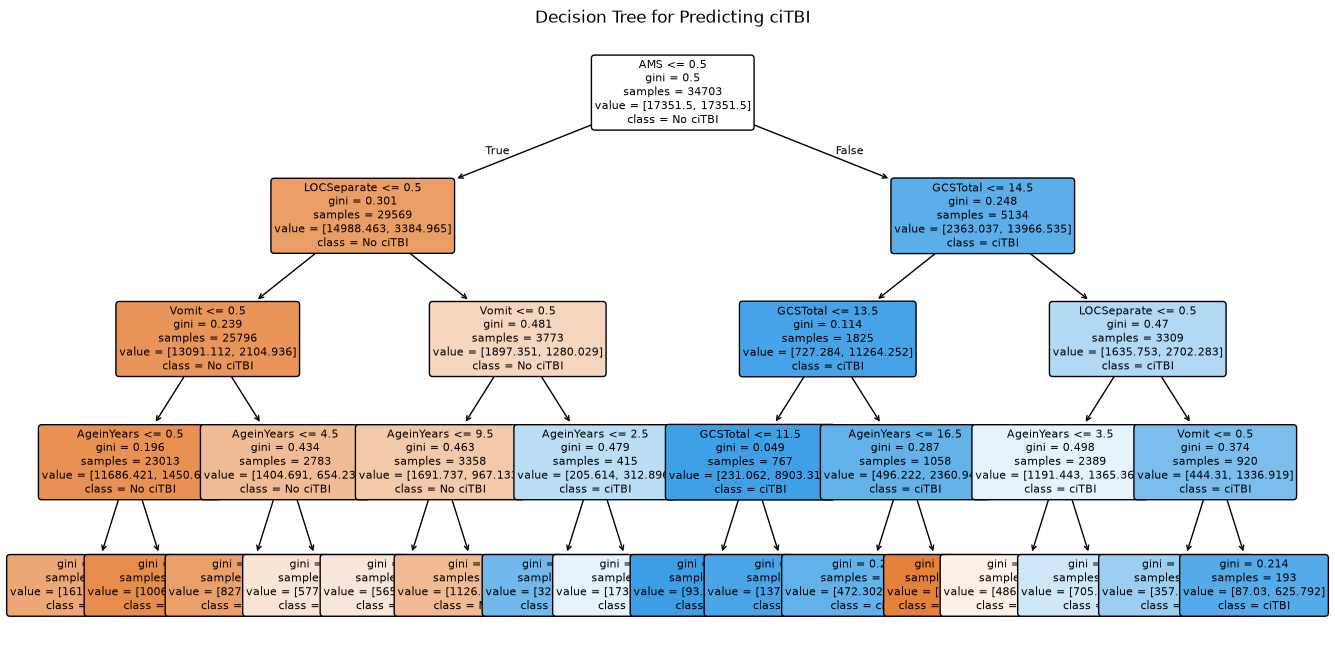

In [46]:
from clean import clean_data

In [47]:
clean2 = clean_data(raw, codebook)

In [48]:
clean2.equals(clean)

True

EDA: Exploratory Data Analysis

### EDA Questions

1. Which individual symptoms are associated with the highest rate of clinically important TBI (ciTBI)?
2. Which combinations of two or three symptoms are associated with the highest rate of ciTBI?

In [49]:
clean["PosIntFinal"].value_counts(dropna=False)

PosIntFinal
0.0    42616
1.0      763
NaN       20
Name: count, dtype: int64

In [50]:
symptoms = [
    "LOCSeparate",
    "Seiz",
    "Vomit",
    "HA_verb",
    "AMS"
]

In [51]:
[col for col in clean.columns if "Vom" in col or "HA" in col or "AMS" in col]

['HA_verb',
 'HASeverity',
 'HAStart',
 'Vomit',
 'VomitNbr',
 'VomitStart',
 'VomitLast',
 'AMS',
 'AMSAgitated',
 'AMSSleep',
 'AMSSlow',
 'AMSRepeat',
 'AMSOth',
 'IndAMS',
 'IndHA',
 'IndVomit']

In [52]:
for symptom in symptoms:
    print("\n", symptom)
    print(
        clean.groupby(symptom)["PosIntFinal"]
        .agg(["mean", "count"])
    )


 LOCSeparate
                 mean  count
LOCSeparate                 
0.0          0.005628  34651
1.0          0.071517   4824
2.0          0.047217   2012

 Seiz
          mean  count
Seiz                 
0.0   0.013352  41867
1.0   0.101667    600

 Vomit
           mean  count
Vomit                 
0.0    0.011741  37135
1.0    0.037401   5802

 HA_verb
             mean  count
HA_verb                 
0.0      0.004346  15877
1.0      0.013830  12798
91.0     0.028606  14053

 AMS
         mean  count
AMS                 
0.0  0.004125  36609
1.0  0.094670   6454


In [53]:
older = clean[clean["AgeinYears"] >= 2]

older.groupby("HA_verb")["PosIntFinal"].agg(["mean", "count"])

,mean,count
HA_verb,,
0.0,0.004437,14875
1.0,0.013857,12773
91.0,0.060947,4266


In [54]:
headache = older[older["HA_verb"].isin([0, 1])]

headache.groupby("HA_verb")["PosIntFinal"].agg(["mean", "count"])

,mean,count
HA_verb,,
0.0,0.004437,14875
1.0,0.013857,12773


question 2

In [55]:
combo2 = (
    clean.groupby(["Seiz", "AMS"])["PosIntFinal"]
    .agg(["mean", "count"])
    .reset_index()
)

combo2

,Seiz,AMS,mean,count
0,0.0,0.0,0.003886,35765
1,0.0,1.0,0.072451,5797
2,1.0,0.0,0.014045,356
3,1.0,1.0,0.231405,242


In [56]:
combo2[
    (combo2["Seiz"] == 1) &
    (combo2["AMS"] == 1)
]

,Seiz,AMS,mean,count
3,1.0,1.0,0.231405,242


In [57]:
from itertools import combinations

In [58]:
pair_results = []

for s1, s2 in combinations(symptoms, 2):
    temp = clean[
        (clean[s1] == 1) &
        (clean[s2] == 1)
    ]

    rate = temp["PosIntFinal"].mean()
    count = temp["PosIntFinal"].count()

    pair_results.append({
        "symptom1": s1,
        "symptom2": s2,
        "ciTBI_rate": rate,
        "count": count
    })

pair_results = pd.DataFrame(pair_results)

In [59]:
pair_results[
    pair_results["count"] >= 30
].sort_values(
    "ciTBI_rate",
    ascending=False
)

,symptom1,symptom2,ciTBI_rate,count
6,Seiz,AMS,0.231405,242
3,LOCSeparate,AMS,0.200000,1530
1,LOCSeparate,Vomit,0.152367,676
4,Seiz,Vomit,0.150538,93
8,Vomit,AMS,0.096810,1818
0,LOCSeparate,Seiz,0.096573,321
9,HA_verb,AMS,0.044657,2508
5,Seiz,HA_verb,0.041096,146
7,Vomit,HA_verb,0.033491,2329
2,LOCSeparate,HA_verb,0.030928,2328


3 symptoms together

In [60]:
triple_results = []

for s1, s2, s3 in combinations(symptoms, 3):
    temp = clean[
        (clean[s1] == 1) &
        (clean[s2] == 1) &
        (clean[s3] == 1)
    ]

    rate = temp["PosIntFinal"].mean()
    count = temp["PosIntFinal"].count()

    triple_results.append({
        "symptom1": s1,
        "symptom2": s2,
        "symptom3": s3,
        "ciTBI_rate": rate,
        "count": count
    })

triple_results = pd.DataFrame(triple_results)

triple_results[
    triple_results["count"] >= 30
].sort_values(
    "ciTBI_rate",
    ascending=False
)

,symptom1,symptom2,symptom3,ciTBI_rate,count
4,LOCSeparate,Vomit,AMS,0.292308,325
2,LOCSeparate,Seiz,AMS,0.243478,115
7,Seiz,Vomit,AMS,0.228070,57
0,LOCSeparate,Seiz,Vomit,0.159091,44
3,LOCSeparate,Vomit,HA_verb,0.089431,369
8,Seiz,HA_verb,AMS,0.080000,50
5,LOCSeparate,HA_verb,AMS,0.068915,682
9,Vomit,HA_verb,AMS,0.062053,838
1,LOCSeparate,Seiz,HA_verb,0.049505,101


Among the symptom combinations examined, LOC + vomiting + altered mental status had the highest observed ciTBI rate (29.2%, n=325).

making figures

In [61]:
finding1 = []

for symptom in ["LOCSeparate", "Seiz", "Vomit", "AMS"]:
    temp = clean[clean[symptom] == 1]
    
    finding1.append({
        "Symptom": symptom,
        "ciTBI_rate": temp["PosIntFinal"].mean(),
        "count": temp["PosIntFinal"].count()
    })

# Headache: only patients age 2+
temp = clean[
    (clean["AgeinYears"] >= 2) &
    (clean["HA_verb"] == 1)
]

finding1.append({
    "Symptom": "HA_verb",
    "ciTBI_rate": temp["PosIntFinal"].mean(),
    "count": temp["PosIntFinal"].count()
})

finding1 = pd.DataFrame(finding1)
finding1

,Symptom,ciTBI_rate,count
0,LOCSeparate,0.071517,4824
1,Seiz,0.101667,600
2,Vomit,0.037401,5802
3,AMS,0.094670,6454
4,HA_verb,0.013857,12773


In [62]:
finding1["Symptom"] = finding1["Symptom"].replace({
    "LOCSeparate": "Loss of consciousness",
    "Seiz": "Seizure",
    "Vomit": "Vomiting",
    "HA_verb": "Headache",
    "AMS": "Altered mental status"
})

In [63]:
finding1 = finding1.sort_values(
    "ciTBI_rate",
    ascending=False
)

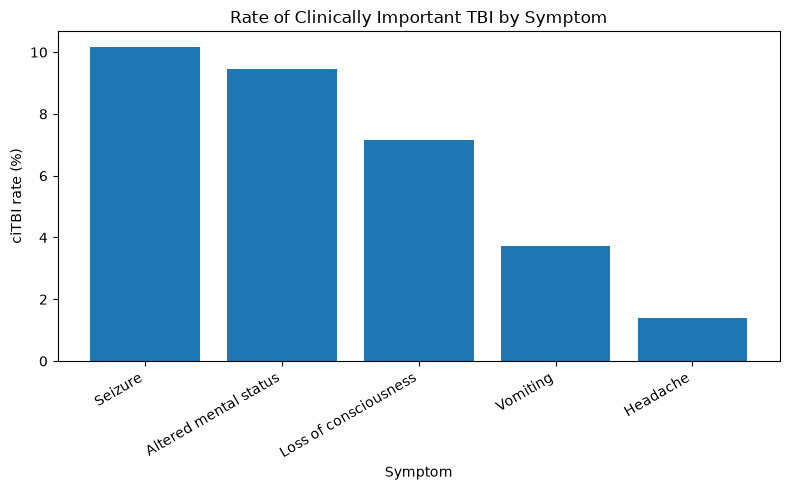

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    finding1["Symptom"],
    finding1["ciTBI_rate"] * 100
)

plt.ylabel("ciTBI rate (%)")
plt.xlabel("Symptom")
plt.title("Rate of Clinically Important TBI by Symptom")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Seizure and altered mental status were associated with the highest observed ciTBI rates among the symptoms examined.

Finding 2: symptom combinations

In [65]:
top_pairs = (
    pair_results[pair_results["count"] >= 30]
    .sort_values("ciTBI_rate", ascending=False)
    .head(4)
    .copy()
)

top_pairs["Combination"] = (
    top_pairs["symptom1"] + " + " +
    top_pairs["symptom2"]
)

In [66]:
top_triples = (
    triple_results[triple_results["count"] >= 30]
    .sort_values("ciTBI_rate", ascending=False)
    .head(4)
    .copy()
)

top_triples["Combination"] = (
    top_triples["symptom1"] + " + " +
    top_triples["symptom2"] + " + " +
    top_triples["symptom3"]
)

In [67]:
finding2 = pd.concat([
    top_pairs[["Combination", "ciTBI_rate", "count"]],
    top_triples[["Combination", "ciTBI_rate", "count"]]
])

finding2 = finding2.sort_values(
    "ciTBI_rate",
    ascending=False
)

In [68]:
finding2

,Combination,ciTBI_rate,count
4,LOCSeparate + Vomit + AMS,0.292308,325
2,LOCSeparate + Seiz + AMS,0.243478,115
6,Seiz + AMS,0.231405,242
7,Seiz + Vomit + AMS,0.228070,57
3,LOCSeparate + AMS,0.200000,1530
0,LOCSeparate + Seiz + Vomit,0.159091,44
1,LOCSeparate + Vomit,0.152367,676
4,Seiz + Vomit,0.150538,93


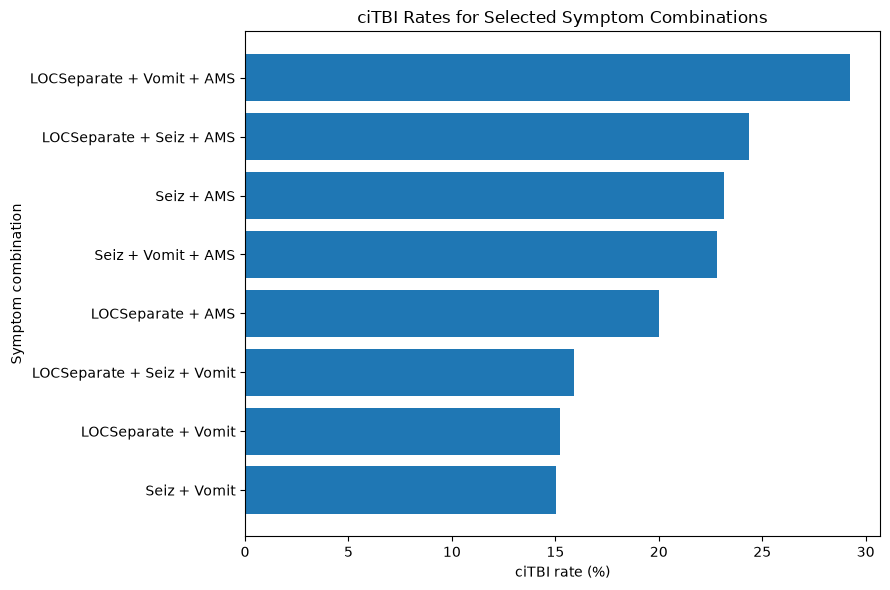

In [69]:
plt.figure(figsize=(9, 6))

plt.barh(
    finding2["Combination"],
    finding2["ciTBI_rate"] * 100
)

plt.xlabel("ciTBI rate (%)")
plt.ylabel("Symptom combination")
plt.title("ciTBI Rates for Selected Symptom Combinations")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [70]:
name_map = {
    "LOCSeparate": "Loss of consciousness",
    "Seiz": "Seizure",
    "Vomit": "Vomiting",
    "HA_verb": "Headache",
    "AMS": "Altered mental status"
}

finding2["Combination"] = finding2["Combination"].replace(
    name_map,
    regex=True
)

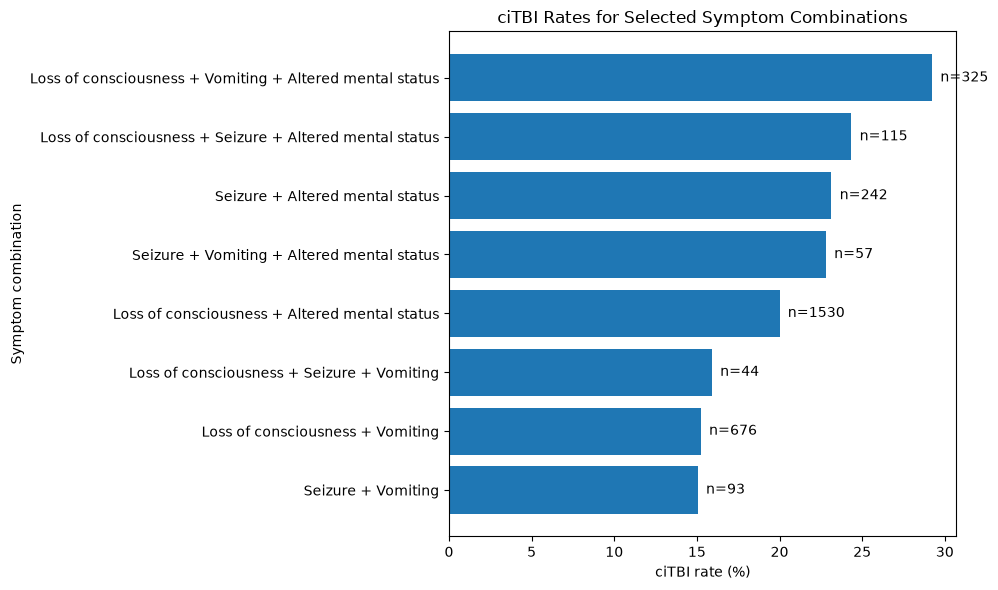

In [71]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    finding2["Combination"],
    finding2["ciTBI_rate"] * 100
)

plt.xlabel("ciTBI rate (%)")
plt.ylabel("Symptom combination")
plt.title("ciTBI Rates for Selected Symptom Combinations")

for bar, n in zip(bars, finding2["count"]):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"n={n}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../report/figure2.png", dpi=300, bbox_inches="tight")
plt.show()

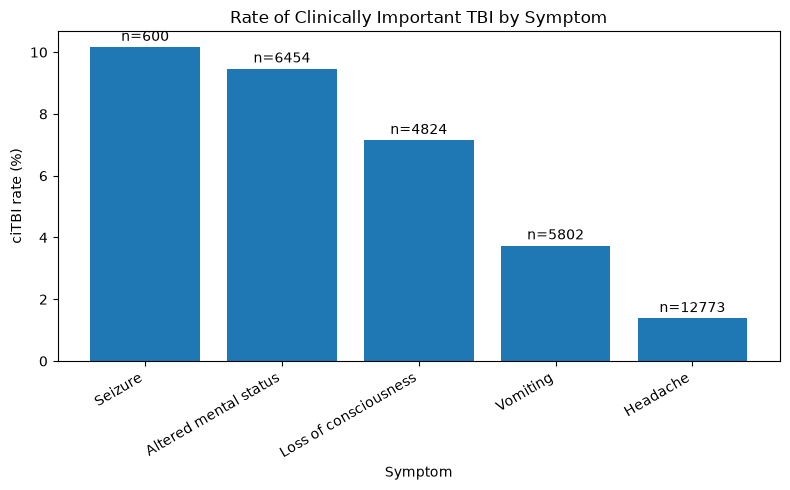

In [72]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    finding1["Symptom"],
    finding1["ciTBI_rate"] * 100
)

plt.ylabel("ciTBI rate (%)")
plt.xlabel("Symptom")
plt.title("Rate of Clinically Important TBI by Symptom")

for bar, n in zip(bars, finding1["count"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"n={n}",
        ha="center"
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../report/figure1.png", dpi=300, bbox_inches="tight")
plt.show()

## Reality Check

The observed patterns are broadly consistent with the clinical context and the Kuppermann et al. study. Symptoms such as altered mental status and loss of consciousness were also important predictors of ciTBI in the original PECARN analysis. This provides some external support that the cleaned data preserve clinically meaningful relationships.

## stability check
cutoff 30 -> 50

In [73]:
stable_pairs = (
    pair_results[pair_results["count"] >= 50]
    .sort_values("ciTBI_rate", ascending=False)
    .head(4)
    .copy()
)

stable_triples = (
    triple_results[triple_results["count"] >= 50]
    .sort_values("ciTBI_rate", ascending=False)
    .head(4)
    .copy()
)

In [74]:
stable_pairs["Combination"] = (
    stable_pairs["symptom1"] + " + " +
    stable_pairs["symptom2"]
)

stable_triples["Combination"] = (
    stable_triples["symptom1"] + " + " +
    stable_triples["symptom2"] + " + " +
    stable_triples["symptom3"]
)

In [75]:
stable_finding2 = pd.concat([
    stable_pairs[["Combination", "ciTBI_rate", "count"]],
    stable_triples[["Combination", "ciTBI_rate", "count"]]
])

stable_finding2 = stable_finding2.sort_values(
    "ciTBI_rate",
    ascending=False
)

In [76]:
stable_finding2["Combination"] = stable_finding2["Combination"].replace(
    name_map,
    regex=True
)

In [77]:
stable_finding2

,Combination,ciTBI_rate,count
4,Loss of consciousness + Vomiting + Altered men...,0.292308,325
2,Loss of consciousness + Seizure + Altered ment...,0.243478,115
6,Seizure + Altered mental status,0.231405,242
7,Seizure + Vomiting + Altered mental status,0.228070,57
3,Loss of consciousness + Altered mental status,0.200000,1530
1,Loss of consciousness + Vomiting,0.152367,676
4,Seizure + Vomiting,0.150538,93
3,Loss of consciousness + Vomiting + Headache,0.089431,369


before and after compariosn

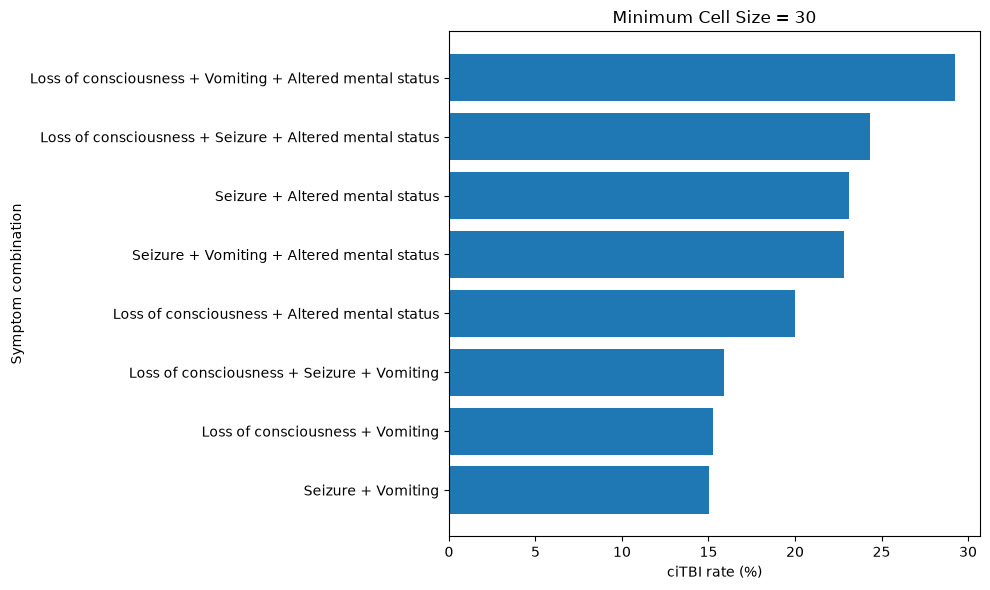

In [78]:
plt.figure(figsize=(10, 6))

plt.barh(
    finding2["Combination"],
    finding2["ciTBI_rate"] * 100
)

plt.xlabel("ciTBI rate (%)")
plt.ylabel("Symptom combination")
plt.title("Minimum Cell Size = 30")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../report/figure3.png", dpi=300, bbox_inches="tight")
plt.show()

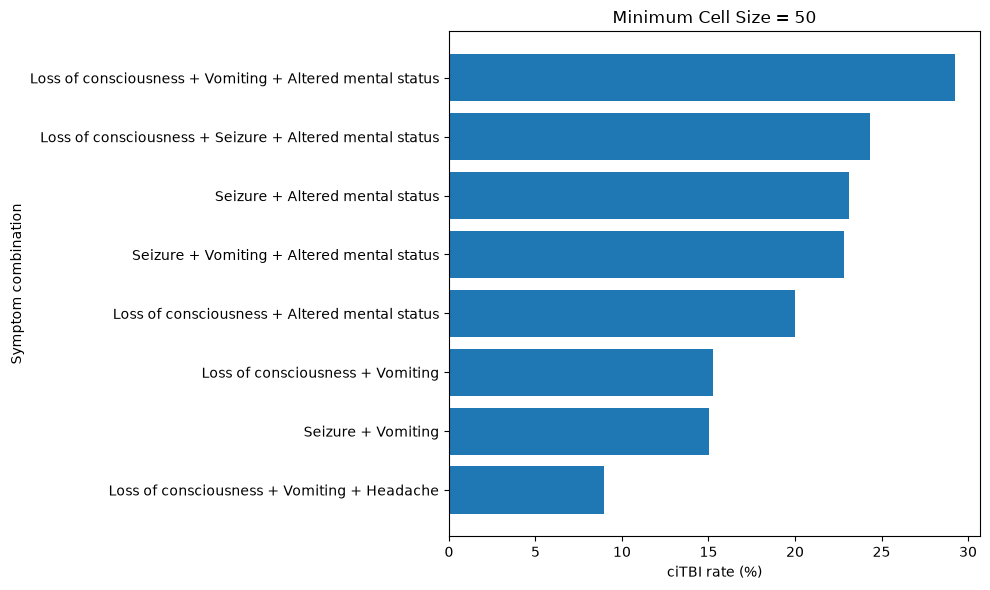

In [79]:
plt.figure(figsize=(10, 6))

plt.barh(
    stable_finding2["Combination"],
    stable_finding2["ciTBI_rate"] * 100
)

plt.xlabel("ciTBI rate (%)")
plt.ylabel("Symptom combination")
plt.title("Minimum Cell Size = 50")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../report/figure4.png", dpi=300, bbox_inches="tight")
plt.show()

Increasing the minimum cell size from 30 to 50 removed some smaller symptom combinations, but the highest-risk combinations remained largely unchanged. This suggests that the main finding is reasonably stable to this threshold choice.

## Part 2: Modeling

I use clinically available pre-CT characteristics to predict clinically important TBI (ciTBI).
I compare logistic regression with a decision tree.

In [80]:
model_data = clean[
    [
        "AgeinYears",
        "GCSTotal",
        "LOCSeparate",
        "Seiz",
        "Vomit",
        "AMS",
        "PosIntFinal"
    ]
].copy()

In [81]:
model_data = model_data.dropna(subset=["PosIntFinal"])

In [82]:
model_data["PosIntFinal"].value_counts()

PosIntFinal
0.0    42616
1.0      763
Name: count, dtype: int64

In [83]:
X = model_data.drop(columns=["PosIntFinal"])
y = model_data["PosIntFinal"]

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

In [86]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

logit.fit(X_train_imp, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [87]:
logit_pred = logit.predict(X_test_imp)

In [88]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=42
)

tree.fit(X_train_imp, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_feat

In [89]:
tree_pred = tree.predict(X_test_imp)

In [90]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    recall_score
)

In [91]:
print("Logistic Regression")
print(confusion_matrix(y_test, logit_pred))
print(classification_report(y_test, logit_pred))

print(
    "Sensitivity:",
    recall_score(y_test, logit_pred)
)

Logistic Regression
[[7291 1232]
 [  33  120]]
              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92      8523
         1.0       0.09      0.78      0.16       153

    accuracy                           0.85      8676
   macro avg       0.54      0.82      0.54      8676
weighted avg       0.98      0.85      0.91      8676

Sensitivity: 0.7843137254901961


In [92]:
print("Decision Tree")
print(confusion_matrix(y_test, tree_pred))
print(classification_report(y_test, tree_pred))

print(
    "Sensitivity:",
    recall_score(y_test, tree_pred)
)

Decision Tree
[[7494 1029]
 [  44  109]]
              precision    recall  f1-score   support

         0.0       0.99      0.88      0.93      8523
         1.0       0.10      0.71      0.17       153

    accuracy                           0.88      8676
   macro avg       0.54      0.80      0.55      8676
weighted avg       0.98      0.88      0.92      8676

Sensitivity: 0.7124183006535948


In [93]:
logit_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logit.coef_[0]
})

logit_coef.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
5,AMS,1.944361
4,Vomit,0.864148
2,LOCSeparate,0.776185
3,Seiz,0.469509
0,AgeinYears,-0.005360
1,GCSTotal,-0.539160


In [94]:
tree_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

tree_importance.sort_values("Importance", ascending=False)

,Feature,Importance
5,AMS,0.823598
1,GCSTotal,0.078860
2,LOCSeparate,0.049258
4,Vomit,0.025537
0,AgeinYears,0.022747
3,Seiz,0.000000


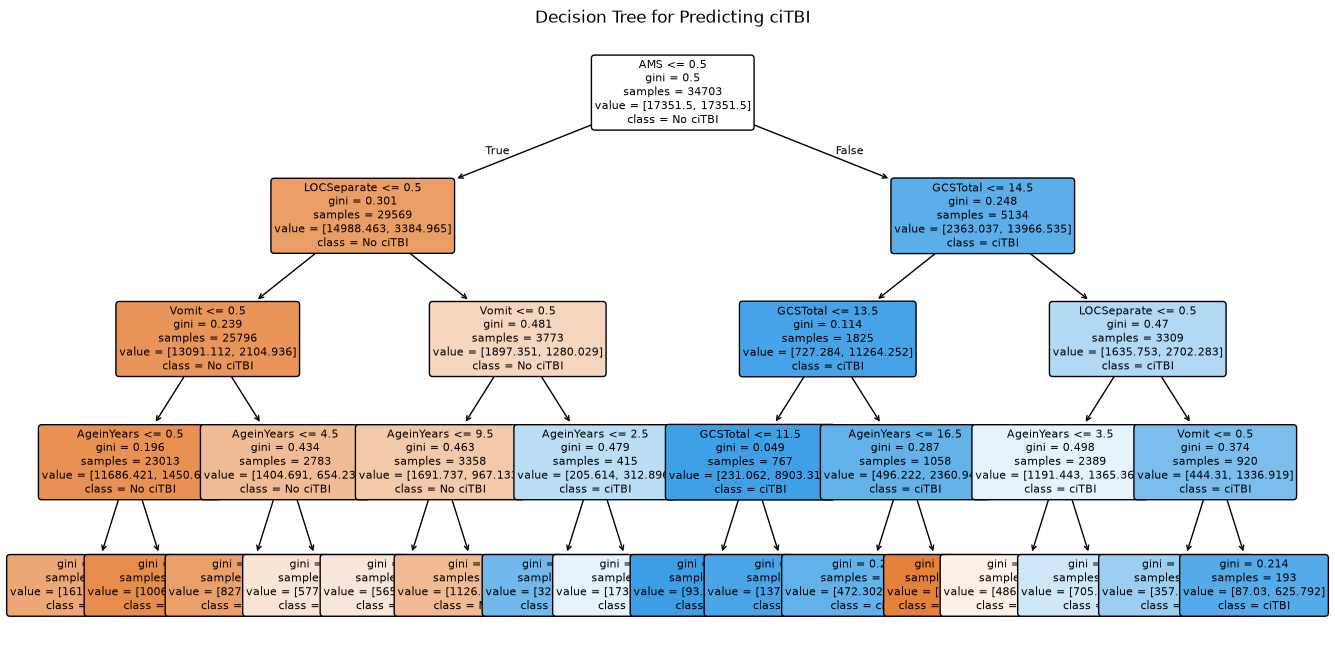

In [95]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No ciTBI", "ciTBI"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Predicting ciTBI")
plt.savefig("../report/figure5.png", dpi=300, bbox_inches="tight")
plt.show()

### Model Interpretation

The logistic regression model had higher sensitivity than the decision tree, identifying about 78% of ciTBI cases compared with about 71% for the decision tree. However, the logistic regression also produced more false positives. Because the main clinical goal is to avoid missing serious brain injuries, sensitivity is especially important in this setting.

In the logistic regression, altered mental status, vomiting, loss of consciousness, and seizure were positively associated with ciTBI, while a higher GCS score was negatively associated with ciTBI. The decision tree also relied heavily on altered mental status, with GCS and loss of consciousness playing smaller roles.

The logistic regression is useful because the direction of each association is easy to interpret, while the decision tree is useful because its prediction process can be represented as a simple sequence of clinical rules. Both models suggest that altered mental status is an important indicator of ciTBI risk.

## Discussion

The dataset was large but manageable. The main challenge was data cleaning because many variables used special codes such as 92 for "not applicable." The documentation was important for understanding which values were true missing values and which had specific meanings.

This lab also shows the three realms of data science. The original clinical setting represents data and reality, the logistic regression and decision tree represent models, and applying these models to future patients represents future data and reality.

The data do not perfectly represent reality. Some symptoms are difficult to measure, some values are missing, and CT decisions are not random. For this reason, the associations in this analysis should not be interpreted as causal.

Overall, altered mental status, seizure, and loss of consciousness were associated with higher ciTBI rates. The logistic regression had higher sensitivity than the decision tree, but it also produced more false positives. This reflects the tradeoff between detecting serious injuries and avoiding unnecessary CT scans.